## Filtering and trimming the messages

- How to customize the graph state schema
- how to define custom state reducers
- how tot use multiple grah state schema


In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

API_KEY = os.getenv('AZURE_OPENAI_API_KEY')
BASE_URL = os.getenv('OPENAI_BASE_URL')

os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ["LANGCHAIN_TRACING_V2"] = "true" # Enable LangSmith tracing
os.environ['LANGSMITH_PROJECT'] = 'LangGraphTraining' # Set the LangSmith project name

In [ ]:
# from langchain_openai import ChatOpenAI
# # llm model
# model = ChatOpenAI(
#     api_key = API_KEY,
#     base_url = BASE_URL,
#     model = 'gpt-4o'
# )

from langchain_aws import ChatBedrockConverse

model = ChatBedrockConverse(model= "us.anthropic.claude-sonnet-4-6",)

# model.invoke('Hi')

AIMessage(content='Hi there! How are you doing? Is there something I can help you with today? 😊', additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': '355e0ef4-663e-4d43-970f-351f2747a63b', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Wed, 12 Aug 2026 08:01:35 GMT', 'content-type': 'application/json', 'content-length': '391', 'connection': 'keep-alive', 'x-amzn-requestid': '355e0ef4-663e-4d43-970f-351f2747a63b'}, 'RetryAttempts': 0}, 'stopReason': 'end_turn', 'metrics': {'latencyMs': [1568]}, 'model_provider': 'bedrock_converse', 'model_name': 'us.anthropic.claude-sonnet-4-6'}, id='lc_run--019ff4fd-a972-79e1-a647-656d46bdfcf3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 24, 'total_tokens': 32, 'input_token_details': {'cache_creation': 0, 'cache_read': 0}})

In [6]:
from pprint import pprint

### Messages
we showed how to use a built-in reducer, `add_messages`, to handle messages in state.

* `MessagesState` has a built-in `messages` key 
* It also has a built-in `add_messages` reducer for this key

In [7]:
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

initial_messages = [
    AIMessage(content="Hello! How can I assist you?", name="model"),
    HumanMessage(content="I'm looking for information on agentic AI.", name="user")
]

new_message = AIMessage(content="Sure, I can help with that. What agentic AI framework are you interested in?", name="model")

add_messages(initial_messages, new_message)

c:\Data\Codes\AgenticAITraining\Lanchain_LangGraph\.venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='model', id='82f3a369-c5f6-41c2-8913-a061766246e0', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on agentic AI.", additional_kwargs={}, response_metadata={}, name='user', id='ee7c90d4-0ac7-464f-858b-e70ea724d56f'),
 AIMessage(content='Sure, I can help with that. What agentic AI framework are you interested in?', additional_kwargs={}, response_metadata={}, name='model', id='046e27dc-70c0-4fef-9a63-3e46064a4e2d', tool_calls=[], invalid_tool_calls=[])]

Using this we can add a message to existing messages list

### Rewriting

We can overwrite the existing message by passing the same id

Let's show some useful tricks when working with the `add_messages` reducer.

If we pass a message with the same ID as an existing one in our `messages` list, it will get overwritten!

In [34]:
# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="model", id="1"),
                    HumanMessage(content="I'm looking for information on agentic AI.", name="user", id="2")
                   ]

# New message to add
new_message = HumanMessage(content="I'm looking for information on LangGraph, specifically", name="user", id="2")
# Test
add_messages(initial_messages , new_message)

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='model', id='1', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on LangGraph, specifically", additional_kwargs={}, response_metadata={}, name='user', id='2')]

### Removal

We can remove messages by using [RemoveMessage](https://docs.langchain.com/oss/python/langgraph/add-memory#delete-messages).

In [35]:
from langchain_core.messages import RemoveMessage

messages = [AIMessage(content = 'Hi, this is a bot', name = 'bot', id = '1')]
messages.append(HumanMessage('Hi', name = 'user', id = '2'))
messages.append(AIMessage('So you said you were researching Agentic AI?', name = 'bot', id = '3'))
messages.append(HumanMessage('Yes, I know about Agentic AI. But what others should I learn about', name = 'user', id = '4'))

# Isolate messaes to delete
del_message = [RemoveMessage(id = m.id) for m in messages[:-2]]

pprint(del_message)
pprint(messages)

[RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='1'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='2')]
[AIMessage(content='Hi, this is a bot', additional_kwargs={}, response_metadata={}, name='bot', id='1', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, name='user', id='2'),
 AIMessage(content='So you said you were researching Agentic AI?', additional_kwargs={}, response_metadata={}, name='bot', id='3', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Yes, I know about Agentic AI. But what others should I learn about', additional_kwargs={}, response_metadata={}, name='user', id='4')]


In [36]:
add_messages(messages, del_message)

[AIMessage(content='So you said you were researching Agentic AI?', additional_kwargs={}, response_metadata={}, name='bot', id='3', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Yes, I know about Agentic AI. But what others should I learn about', additional_kwargs={}, response_metadata={}, name='user', id='4')]

The messsages are not deleted by default, we have to add the messages after pasitng it to the remove message

In [12]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage


messages = [
    AIMessage("Hello! I'm your Delivery Assistant. How can I help you today?", name="Support_Bot")
]

# 2. The User responds (Real-time input)
messages.append(
    HumanMessage("My package #12345 says 'Delivered' but I don't see it.", name="Customer")
)

# 3. The Bot asks a follow-up based on that input
messages.append(
    AIMessage("I'm sorry to hear that. Have you checked with your neighbors or behind the side gate?", name="Support_Bot")
)

# 4. The User answers again
messages.append(
    HumanMessage("I checked the gate, but not the neighbors. I'll go look.", name="Customer")
)

# Print the whole "transcript"

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Support_Bot

Hello! I'm your Delivery Assistant. How can I help you today?
================================ Human Message =================================
Name: Customer

My package #12345 says 'Delivered' but I don't see it.
================================== Ai Message ==================================
Name: Support_Bot

I'm sorry to hear that. Have you checked with your neighbors or behind the side gate?
================================ Human Message =================================
Name: Customer

I checked the gate, but not the neighbors. I'll go look.


In [8]:
from langgraph.graph.message import add_messages
from typing_extensions import TypedDict, Annotated
from langchain_core.messages import BaseMessage, AnyMessage, HumanMessage, AIMessage
from IPython.display import Markdown
from langgraph.graph import StateGraph, START, END

class ChatBotState(TypedDict):
    messages: Annotated[list[AnyMessage],add_messages] 

def assistance(state: ChatBotState):
    return {"messages": model.invoke(state["messages"])}

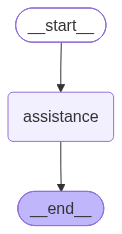

In [9]:
builder = StateGraph(ChatBotState)

builder.add_node("assistance", assistance)

builder.add_edge(START, "assistance")
builder.add_edge("assistance", END)

graph = builder.compile()
graph

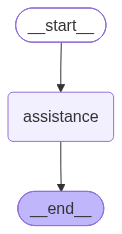

In [10]:
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END

# Node
def assistance(state: MessagesState):
    return {"messages": model.invoke(state["messages"])}

# Build graph
builder = StateGraph(MessagesState)

builder.add_node("assistance", assistance)

builder.add_edge(START, "assistance")
builder.add_edge("assistance", END)

graph = builder.compile()

graph

Both are same graph, using the inbuilt MessagesState makes the work easier where we don't have to create our own state

In [13]:
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Support_Bot

Hello! I'm your Delivery Assistant. How can I help you today?
================================ Human Message =================================
Name: Customer

My package #12345 says 'Delivered' but I don't see it.
================================== Ai Message ==================================
Name: Support_Bot

I'm sorry to hear that. Have you checked with your neighbors or behind the side gate?
================================ Human Message =================================
Name: Customer

I checked the gate, but not the neighbors. I'll go look.
================================== Ai Message ==================================

That's a great idea! Sometimes delivery drivers leave packages with neighbors for safekeeping. While you check, here are a few other things to look into:

1. **Check around your property** - Look behind bushes, on your porch, or any covered areas
2. **Ask other ho

In [14]:
model.invoke('Hi how are you')

AIMessage(content="Hi! I'm doing well, thanks for asking! How are you doing? Is there something I can help you with today? 😊", additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': '13ce72c7-9332-495b-8ceb-6f2dd15f058d', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Wed, 12 Aug 2026 08:40:40 GMT', 'content-type': 'application/json', 'content-length': '421', 'connection': 'keep-alive', 'x-amzn-requestid': '13ce72c7-9332-495b-8ceb-6f2dd15f058d'}, 'RetryAttempts': 0}, 'stopReason': 'end_turn', 'metrics': {'latencyMs': [1551]}, 'model_provider': 'bedrock_converse', 'model_name': 'us.anthropic.claude-sonnet-4-6'}, id='lc_run--019ff521-76a3-7481-968d-6958b3b5a76b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 32, 'total_tokens': 43, 'input_token_details': {'cache_creation': 0, 'cache_read': 0}})

### Trim Messages

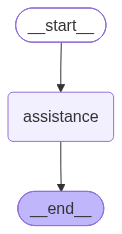

In [16]:
from langchain_core.messages import trim_messages

# Node
def assistance(state: MessagesState):
    messaages = trim_messages(
        state['messages'],
        max_tokens = 100,
        strategy = 'last',
        token_counter = ChatBedrockConverse(model= "us.anthropic.claude-sonnet-4-6"),
        allow_partial = False
    )
    return {'messages': model.invoke(messaages)}

builder = StateGraph(MessagesState)
builder.add_node("assistance", assistance)
builder.add_edge(START, "assistance")
builder.add_edge("assistance", END)
graph = builder.compile()
graph


In [17]:
output['messages']

[AIMessage(content="Hello! I'm your Delivery Assistant. How can I help you today?", additional_kwargs={}, response_metadata={}, name='Support_Bot', id='2180ad19-0529-44f7-b960-68fe5af33d41', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="My package #12345 says 'Delivered' but I don't see it.", additional_kwargs={}, response_metadata={}, name='Customer', id='bbea582f-8f27-42b2-b309-50464f545e4a'),
 AIMessage(content="I'm sorry to hear that. Have you checked with your neighbors or behind the side gate?", additional_kwargs={}, response_metadata={}, name='Support_Bot', id='867f1e46-9220-4ecb-93f7-40561f336f58', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I checked the gate, but not the neighbors. I'll go look.", additional_kwargs={}, response_metadata={}, name='Customer', id='0875ab9a-f877-4e71-8818-63977ecaef51'),
 AIMessage(content="That's a great idea! Sometimes delivery drivers leave packages with neighbors for safekeeping. While you check, here are a f

In [18]:
output['messages'][-1]

AIMessage(content="That's a great idea! Sometimes delivery drivers leave packages with neighbors for safekeeping. While you check, here are a few other things to look into:\n\n1. **Check around your property** - Look behind bushes, on your porch, or any covered areas\n2. **Ask other household members** - Someone else may have brought it inside\n3. **Check your mailbox** - Smaller packages sometimes fit inside\n4. **Look for a delivery notice** - The driver may have left a note with pickup instructions\n\nIf you still can't find it after checking with your neighbors, please come back and let me know and we can:\n- 📋 **File a missing package report**\n- 🔍 **Investigate with the carrier**\n- 🔄 **Explore replacement or refund options**\n\nHope you find it soon! 😊", additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': '495c307c-81ca-4479-9eff-3d97b66192f0', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Wed, 12 Aug 2026 08:40:31 GMT', 'content-type': 'application/json

In [19]:
messages.append(output['messages'][-1]) # Append the latest bot response
messages.append(HumanMessage("I still can't find my package. Can you help me escalate this issue?", name="Customer", id="7")) # append a follow-up question

In [20]:
for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Support_Bot

Hello! I'm your Delivery Assistant. How can I help you today?
================================ Human Message =================================
Name: Customer

My package #12345 says 'Delivered' but I don't see it.
================================== Ai Message ==================================
Name: Support_Bot

I'm sorry to hear that. Have you checked with your neighbors or behind the side gate?
================================ Human Message =================================
Name: Customer

I checked the gate, but not the neighbors. I'll go look.
================================== Ai Message ==================================

That's a great idea! Sometimes delivery drivers leave packages with neighbors for safekeeping. While you check, here are a few other things to look into:

1. **Check around your property** - Look behind bushes, on your porch, or any covered areas
2. **Ask other ho

In [ ]:
# Dont know what is the issue

# trim_messages(
#     messages,
#     max_tokens=100,
#     strategy="last",
#     token_counter=ChatBedrockConverse(model= "us.anthropic.claude-sonnet-4-6",),
#     allow_partial=False
# )

In [27]:
messages_out_trim = graph.invoke({'messages': messages})

count_tokens API failed: An error occurred (ValidationException) when calling the CountTokens operation: This model does not support assistant message prefill. The conversation must end with a user message.. Using fallback.


ImportError: Could not import transformers python package. This is needed in order to calculate get_token_ids. Please install it with `pip install transformers`.